# Build a model

Are the signals from `pbs-1`, `pbs-2`, and `pbs-3` sufficiently discrimatory of human breast cancer?


```
variation.update({
    'q_high': 0.95
})
```

## 0. Initializations

In [1]:
## 0. Initializations
# -- imports --
import anndata as ad
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns

import random

from collections import defaultdict

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from statistics import median

from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes
from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [2]:
# -- datasets --
gse = GSE161529()

## 1. Preprocessing Data

1. Subset data to samples that have a potential biological signal.
2. Determine the distribution of number of samples per subject - use to downsample for parity.
3. Determine the distribution of number of cells per subject - use to downsample for parity

In [3]:
initial = {
    'q_low': 0.25,
    'q_high': 0.75
}
variation = initial.copy()
variation.update({
    'q_high': 0.95
})
print(f"kwargs: {variation}")

kwargs: {'q_low': 0.25, 'q_high': 0.95}


In [4]:
# -- subset data --
subtype_to_adata = defaultdict(dict)
choices = ["pbs-1", "pbs-2", "pbs-3"]
for adata in gse.objects.values():
    adata_noise = adata[adata.obs["is_noise"] == 1].copy()
    classify_noise_subtypes(adata_noise, **variation)
    conditions = [
        adata_noise.obs["pbs-1"] == 1,
        adata_noise.obs["pbs-2"] == 1,
        adata_noise.obs["pbs-3"] == 1,
    ]
    adata_noise.obs["pbs"] = np.select(conditions, choices, default="none")
    adata_pbs_only = adata_noise[adata_noise.obs["pbs"] != "none"]
    subtype_to_adata[adata_pbs_only.uns['cancer_type']].update({
        adata_pbs_only.uns['title'] : adata_pbs_only
    })

In [5]:
subtype_to_adata.keys()

dict_keys(['Normal', 'BRCA1 pre-neoplastic', 'Triple negative tumour', 'Triple negative BRCA1 tumour', 'HER2+ tumour', 'PR+ tumour', 'ER+ tumour'])

In [6]:
def print_data_stats(adata_collection):
    results = []
    for subtype, adatas in adata_collection.items():
        num_subjects = len(adatas)
        num_samples = [adata.n_obs for adata in adatas.values()]
        print(f"{subtype} - {num_samples}")
        results.append((subtype, num_subjects, min(num_samples), median(num_samples)))
    
    return pd.DataFrame(results, columns=['Cancer sub-type', '# Subjects', 'Min # Samples', 'Median # Samples'])

print_data_stats(subtype_to_adata)

Normal - [26, 68, 9, 187, 412, 15, 10, 30, 11, 34, 18, 25, 34, 23, 9, 48, 38, 69, 28, 37, 22, 26, 169, 124]
BRCA1 pre-neoplastic - [38, 28, 60, 50]
Triple negative tumour - [24, 57, 13, 55]
Triple negative BRCA1 tumour - [39, 73, 152, 252]
HER2+ tumour - [46, 231, 42, 6, 73, 364]
PR+ tumour - [31]
ER+ tumour - [196, 152, 89, 66, 11, 45, 125, 42, 73, 76, 40, 36, 65, 29, 71, 26, 20, 2, 268, 233, 57, 73, 443, 11, 6]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,24,9,29.0
1,BRCA1 pre-neoplastic,4,28,44.0
2,Triple negative tumour,4,13,39.5
3,Triple negative BRCA1 tumour,4,39,112.5
4,HER2+ tumour,6,6,59.5
5,PR+ tumour,1,31,31.0
6,ER+ tumour,25,2,65.0


### 1.a. Decisions

1. Exclude cancer sub-type `PR+ tumour` because there is only a single subject in the dataset.
2. Downsample subjects to `3` with a minimum of `50` samples.

### 1.b. Further subset data

Produces a dataset with the decisions.

In [7]:
def subset_data_for_modeling(require_min_subject=True, require_min_samples=True):
    results = {}
    for subtype, adatas in subtype_to_adata.items():
        if require_min_subject and subtype == 'PR+ tumour':
            # only has one subject, exclude
            continue
        valid_subjects_to_adata = defaultdict(dict)
        for adata in adatas.values():
            if require_min_samples and adata.n_obs < 50:
                # exclude subjects with fewer than 50 samples
                continue
            valid_subjects_to_adata.update({
                adata.uns['title']: adata,
            })
        results[subtype] = valid_subjects_to_adata
    return results
valid_adatas = subset_data_for_modeling()

In [8]:
print_data_stats(valid_adatas)

Normal - [68, 187, 412, 69, 169, 124]
BRCA1 pre-neoplastic - [60, 50]
Triple negative tumour - [57, 55]
Triple negative BRCA1 tumour - [73, 152, 252]
HER2+ tumour - [231, 73, 364]
ER+ tumour - [196, 152, 89, 66, 125, 73, 76, 65, 71, 268, 233, 57, 73, 443]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,6,68,146.5
1,BRCA1 pre-neoplastic,2,50,55.0
2,Triple negative tumour,2,55,56.0
3,Triple negative BRCA1 tumour,3,73,152.0
4,HER2+ tumour,3,73,231.0
5,ER+ tumour,14,57,82.5


### 1.3. Utility to Generate Dataset for Modeling

Creates a list of dataframe from the AnnDatas that represents all cancer sub-types (except for `PR+ tumour`), with the following characteristics:

1. `3` subjects per sub-type, `6` sub-types = `18` total subjects
2. `1` dataframe per subject
3. Columns
   1. `has_cancer`
   2. `cancer_type`
   3. `cell_population`
   4. `menopause_status`
   5. `pbs-1`
   6. `pbs-2`
   7. `pbs-3`

Separating the subjects to a row will simplify using the leave-one-out strategy.

In [9]:
def generate_dataframe_for_modeling(downsample=True):
    results = []
    for adatas in valid_adatas.values():
        if downsample:
            subjects = np.random.choice(list(adatas.keys()), 3)
        else:
            subjects = adatas.keys()

        for subject in subjects:
            adata = adatas[subject]
            df = pd.DataFrame({
                'pbs-1': adata.obs['pbs-1'].astype(int),
                'pbs-2': adata.obs['pbs-2'].astype(int),
                'pbs-3': adata.obs['pbs-3'].astype(int),
            })
            df['has_cancer'] = (adata.uns['cancer_type'] != 'Normal')
            df['cancer_type'] = str(adata.uns['cancer_type'])
            df['cell_population'] = str(adata.uns['cell_population'])
            df['menopause_status'] = str(adata.uns['menopause_status'])
            
            results.append(df)
    return results

In [10]:
generate_dataframe_for_modeling()[0]

,pbs-1,pbs-2,pbs-3,has_cancer,cancer_type,cell_population,menopause_status
AAAGTCCTCTCGTCAC-1,0,1,0,False,Normal,Epithelial,Pre
AACAAGAGTGTACAGG-1,1,0,0,False,Normal,Epithelial,Pre
AACAGGGAGTTGGCGA-1,0,1,0,False,Normal,Epithelial,Pre
AACCCAAAGGTCGACA-1,0,1,0,False,Normal,Epithelial,Pre
AAGCGAGGTAAGGAGA-1,0,1,0,False,Normal,Epithelial,Pre
...,...,...,...,...,...,...,...
TTGTTGTGTCGGATTT-1,0,1,0,False,Normal,Epithelial,Pre
TTTACTGTCGTGTGAT-1,1,0,0,False,Normal,Epithelial,Pre
TTTCAGTAGGCGAAGG-1,0,1,0,False,Normal,Epithelial,Pre
TTTCATGTCCTAGCCT-1,0,1,0,False,Normal,Epithelial,Pre


## 2. Build the classifier

In [11]:
def logistic_regression_loo_classifier(dfs, *, by_subjects=True, as_dict=False, model=None, target='cancer_type'):
    loo = LeaveOneOut()
    y_true, y_pred = [], []
    
    for train_idx, test_idx in loo.split(dfs):
        train_df = pd.concat([dfs[i] for i in train_idx])
        # there will only ever be one in the test
        test_df = dfs[test_idx[0]]
    
        X_train = train_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_train = train_df[target].values
    
        X_test = test_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_test = test_df[target].values

        if not model:
            model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
    
        if by_subjects:
            counts = np.unique(model.predict(X_test), return_counts=True)
            # return the majority vote for the subject
            y_pred.append(counts[0][np.argmax(counts[1])])
            y_true.append(test_df[target].iloc[0])
        else:
            y_pred.extend(model.predict(X_test))
            y_true.extend(y_test)
    
    return classification_report(y_true, y_pred, output_dict=as_dict)

# dfs = generate_dataframe_for_modeling()
# print(logistic_regression_loo_classifier(dfs))

In [12]:
# from sklearn.model_selection import LeaveOneOut
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# reports = []
# by_subject = False
# for run in range(10):
#     dfs = generate_dataframe_for_modeling()
#     report = logistic_regression_loo_classifier(dfs, as_dict=True)
#     reports.append(pd.DataFrame(report).T)

In [13]:
# avg_report = pd.concat(reports).groupby(level=0).mean()
# std_report = pd.concat(reports).groupby(level=0).std()

# print("Mean:")
# print(avg_report)
# print("\nStd:")
# print(std_report)

In [14]:
# dfs = generate_dataframe_for_modeling(downsample=False)
# print(logistic_regression_loo_classifier(dfs))

In [15]:
# dfs = generate_dataframe_for_modeling(downsample=False)
# print(logistic_regression_loo_classifier(dfs, by_subjects=False))

### 2.1. Explore other models

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import warnings
from sklearn.exceptions import UndefinedMetricWarning

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Naive Bayes': GaussianNB()
}

# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
#     n_runs = 100
#     for model_name, model in models.items():
#         reports = []
#         all_y_true, all_y_pred = [], []
        
#         for run in range(n_runs):
#             dfs = generate_dataframe_for_modeling(downsample=False)
#             report = logistic_regression_loo_classifier(dfs, by_subjects=False, as_dict=True, model=model)
#             reports.append(pd.DataFrame(report).T)
    
#         avg_report = pd.concat(reports).groupby(level=0).mean()
    
#         print(f"{'='*25}")
#         print(f"Model: {model_name}")
#         print(f"{'-'*25}")
#         print(f"Mean: {avg_report}")
#         print()

In [17]:
# pd.concat(dfs).groupby('has_cancer')[['pbs-1','pbs-2','pbs-3']].mean()

### 2.2. Model ANY cancer

In [18]:
# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
#     n_runs = 100
#     for model_name, model in models.items():
#         reports = []
        
#         for run in range(n_runs):
#             dfs = generate_dataframe_for_modeling(downsample=False)
#             report = logistic_regression_loo_classifier(dfs, by_subjects=False, as_dict=True, model=model, target="has_cancer")
#             reports.append(pd.DataFrame(report).T)
    
#         avg_report = pd.concat(reports).groupby(level=0).mean()
    
#         print(f"{'='*25}")
#         print(f"Model: {model_name}")
#         print(f"{'-'*25}")
#         print(f"Mean: {avg_report}")
#         print()

In [19]:
# pd.concat(dfs).groupby('has_cancer')[['pbs-1','pbs-2','pbs-3']].mean()

In [20]:
# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
#     n_runs = 100
#     for model_name, model in models.items():
#         reports = []
        
#         for run in range(n_runs):
#             dfs = generate_dataframe_for_modeling(downsample=False)
#             report = logistic_regression_loo_classifier(dfs, by_subjects=False, as_dict=True, model=model, target="has_cancer")
#             reports.append(pd.DataFrame(report).T)
    
#         avg_report = pd.concat(reports).groupby(level=0).mean()
    
#         print(f"{'='*25}")
#         print(f"Model: {model_name}")
#         print(f"{'-'*25}")
#         print(f"Mean: {avg_report}")
#         print()

#### 2.3.1 Need to downsample to proceed

There are much more cancer than normal, this is skewing the results.

There are only `6` normal subjects.

In [21]:
dfs = generate_dataframe_for_modeling(downsample=False)

In [43]:
dfs[1]['cancer_type'].unique()[0]

'Normal'

In [22]:
dfs_cancer = []
dfs_normal = []

for df in dfs:
    if df['cancer_type'].unique()[0] == 'Normal':
        dfs_normal.append(df)
    else:
        dfs_cancer.append(df)

In [51]:
downsample_indices = random.sample(range(len(dfs_cancer)), len(dfs_normal)-1)
subset_cancer = [dfs_cancer[idx] for idx in downsample_indices]
dfs = dfs_normal.copy()
dfs.extend(subset_cancer)

balanced_df = pd.concat(dfs)
print(balanced_df['has_cancer'].value_counts())

has_cancer
False    1029
True     1022
Name: count, dtype: int64


In [57]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
    n_runs = 1000
    for model_name, model in models.items():
        reports = []
        for run in range(n_runs):
            downsample_indices = random.sample(range(len(dfs_cancer)), len(dfs_normal))
            subset_cancer = [dfs_cancer[idx] for idx in downsample_indices]
            dfs = dfs_normal.copy()
            dfs.extend(subset_cancer)
            
            report = logistic_regression_loo_classifier(dfs, by_subjects=False, as_dict=True, model=model, target="has_cancer")
            reports.append(pd.DataFrame(report).T)
    
        avg_report = pd.concat(reports).groupby(level=0).mean()
    
        print(f"{'='*25}")
        print(f"Model: {model_name}")
        print(f"{'-'*25}")
        print(f"Mean: {avg_report}")
        print()

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score      support
False          0.585668  0.772867  0.665124  1029.000000
True           0.619468  0.342079  0.429355   840.138000
accuracy       0.596911  0.596911  0.596911     0.596911
macro avg      0.602568  0.557473  0.547240  1869.138000
weighted avg   0.604446  0.596911  0.571779  1869.138000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score      support
False          0.591283  0.781164  0.671822  1029.000000
True           0.629884  0.345719  0.435259   836.151000
accuracy       0.603083  0.603083  0.603083     0.603083
macro avg      0.610584  0.563442  0.553541  1865.151000
weighted avg   0.612066  0.603083  0.578034  1865.151000

Model: KNN
-------------------------
Mean:               precision    recall  f1-score      support
False          0.559428  0.998268  0.714676  1029.000000
True           0.013297  0.000414  0.000798  

In [58]:
# ── DATA from avg_report ─────────────────────────────────────────────────────
support_false = avg_report.loc["False", "support"]
support_true  = avg_report.loc["True",  "support"]
recall_false  = avg_report.loc["False", "recall"]
recall_true   = avg_report.loc["True",  "recall"]
accuracy      = avg_report.loc["accuracy",     "f1-score"]
macro_f1      = avg_report.loc["macro avg",    "f1-score"]
f1_false      = avg_report.loc["False", "f1-score"]
f1_true       = avg_report.loc["True",  "f1-score"]
precision_false = avg_report.loc["False", "precision"]
precision_true  = avg_report.loc["True",  "precision"]

# reconstructed cm
tn = round(support_false * recall_false)
fp = round(support_false * (1 - recall_false))
fn = round(support_true  * (1 - recall_true))
tp = round(support_true  * recall_true)

cm       = np.array([[tn, fp], [fn, tp]])
support  = [support_false, support_true]

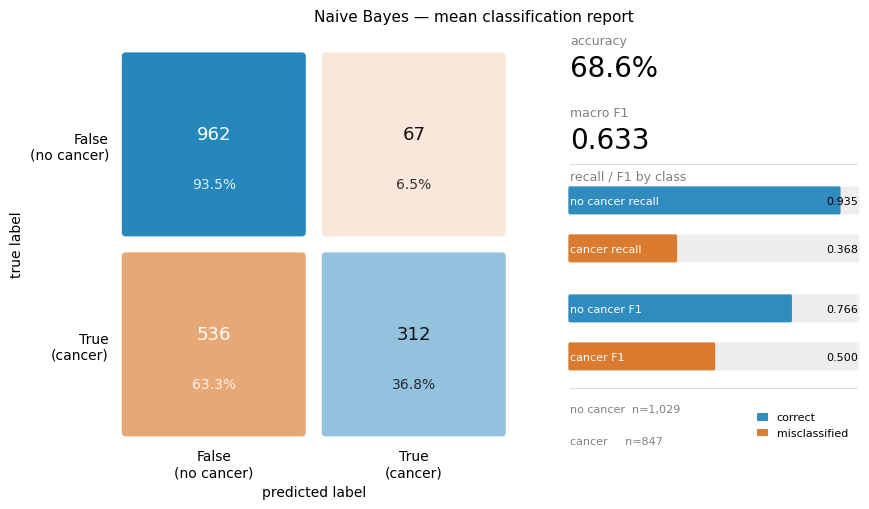

In [70]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ── DATA from avg_report ─────────────────────────────────────────────────────
support_false   = avg_report.loc["False",     "support"]
support_true    = avg_report.loc["True",      "support"]
recall_false    = avg_report.loc["False",     "recall"]
recall_true     = avg_report.loc["True",      "recall"]
precision_false = avg_report.loc["False",     "precision"]
precision_true  = avg_report.loc["True",      "precision"]
f1_false        = avg_report.loc["False",     "f1-score"]
f1_true         = avg_report.loc["True",      "f1-score"]
accuracy        = avg_report.loc["accuracy",  "f1-score"]
macro_f1        = avg_report.loc["macro avg", "f1-score"]

tn = round(support_false * recall_false)
fp = round(support_false * (1 - recall_false))
fn = round(support_true  * (1 - recall_true))
tp = round(support_true  * recall_true)

cm      = np.array([[tn, fp], [fn, tp]])
support = [support_false, support_true]
blue    = "#0072B2"
orange  = "#D55E00"

# ── FIGURE ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 5))

ax_cm     = fig.add_axes([0.05, 0.10, 0.50, 0.80])
ax_metric = fig.add_axes([0.62, 0.10, 0.36, 0.80])

# ── CONFUSION MATRIX ─────────────────────────────────────────────────────────
classes = ["False\n(no cancer)", "True\n(cancer)"]

for i in range(2):
    for j in range(2):
        val = cm[i, j]
        pct = val / support[i] if support[i] > 0 else 0

        if i == j:
            color = blue
            alpha = 0.15 + pct * 0.75
        else:
            color = orange
            alpha = 0.10 + pct * 0.70

        rect = patches.FancyBboxPatch(
            (j + 0.06, 1 - i + 0.06), 0.88, 0.88,
            boxstyle="round,pad=0.02",
            facecolor=color, alpha=max(alpha, 0.08),
            linewidth=0
        )
        ax_cm.add_patch(rect)

        text_color = "white" if pct > 0.4 else "#111111"
        ax_cm.text(j + 0.5, 1 - i + 0.55, f"{int(val):,}",
                   ha="center", va="center",
                   fontsize=13, fontweight="500", color=text_color)
        ax_cm.text(j + 0.5, 1 - i + 0.30, f"{pct:.1%}",
                   ha="center", va="center",
                   fontsize=10, color=text_color, alpha=0.85)

ax_cm.set_xticks([0.5, 1.5])
ax_cm.set_xticklabels(classes, fontsize=10)
ax_cm.set_yticks([0.5, 1.5])
ax_cm.set_yticklabels(classes[::-1], fontsize=10)
ax_cm.set_xlim(0, 2)
ax_cm.set_ylim(0, 2)
ax_cm.set_xlabel("predicted label", fontsize=10)
ax_cm.set_ylabel("true label", fontsize=10)
ax_cm.spines[:].set_visible(False)
ax_cm.tick_params(length=0)

# from matplotlib.patches import Patch
# legend_elements = [
#     Patch(facecolor=blue,   alpha=0.7, label="correct"),
#     Patch(facecolor=orange, alpha=0.7, label="misclassified"),
# ]
# ax_cm.legend(handles=legend_elements, loc="upper left",
#              frameon=False, fontsize=8,
#              bbox_to_anchor=(0, -0.08), ncol=2, handlelength=1)

# ── METRICS PANEL ────────────────────────────────────────────────────────────
ax_metric.axis("off")

ax_metric.text(0, 1.00, "accuracy",       transform=ax_metric.transAxes,
               fontsize=9, color="gray")
ax_metric.text(0, 0.92, f"{accuracy:.1%}", transform=ax_metric.transAxes,
               fontsize=20, fontweight="500")
ax_metric.text(0, 0.82, "macro F1",       transform=ax_metric.transAxes,
               fontsize=9, color="gray")
ax_metric.text(0, 0.74, f"{macro_f1:.3f}", transform=ax_metric.transAxes,
               fontsize=20, fontweight="500")

ax_metric.axhline(y=0.70, xmin=0, xmax=1,
                  color="#CCCCCC", linewidth=0.5)

ax_metric.text(0, 0.66, "recall / F1 by class", transform=ax_metric.transAxes,
               fontsize=9, color="gray")

metrics = [
    ("no cancer recall", recall_false, blue),
    ("cancer recall",    recall_true,  orange),
    ("no cancer F1",     f1_false,     blue),
    ("cancer F1",        f1_true,      orange),
]

bar_y = [0.58, 0.46, 0.31, 0.19]

for (label, val, color), y in zip(metrics, bar_y):
    ax_metric.text(0, y + 0.02, label, transform=ax_metric.transAxes,
                   fontsize=8, color="white")
    ax_metric.text(1, y + 0.02, f"{val:.3f}", transform=ax_metric.transAxes,
                   fontsize=8, color="black", ha="right")
    ax_metric.add_patch(patches.FancyBboxPatch(
        (0, y), 1, 0.06,
        boxstyle="round,pad=0.005",
        transform=ax_metric.transAxes,
        facecolor="#EEEEEE", linewidth=0, clip_on=False
    ))
    if val > 0.001:
        ax_metric.add_patch(patches.FancyBboxPatch(
            (0, y), val, 0.06,
            boxstyle="round,pad=0.005",
            transform=ax_metric.transAxes,
            facecolor=color, alpha=0.8, linewidth=0, clip_on=False
        ))

ax_metric.axhline(y=0.14, xmin=0, xmax=1,
                  color="#CCCCCC", linewidth=0.5)

ax_metric.text(0, 0.08, f"no cancer  n={int(support_false):,}",
               transform=ax_metric.transAxes, fontsize=8, color="gray")
ax_metric.text(0, 0.00, f"cancer     n={int(support_true):,}",
               transform=ax_metric.transAxes, fontsize=8, color="gray")

legend_elements = [
    Patch(facecolor=blue,   alpha=0.8, label="correct"),
    Patch(facecolor=orange, alpha=0.8, label="misclassified"),
]
ax_metric.legend(handles=legend_elements,
                 loc="lower right",
                 bbox_to_anchor=(1, -0.01),
                 frameon=False, fontsize=8,
                 ncol=1, handlelength=1)

plt.suptitle("Naive Bayes — mean classification report", fontsize=11, y=0.97)
plt.savefig("images/umsi-expo-figure-4.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
    n_runs = 100
    for model_name, model in models.items():
        reports = []
        for run in range(n_runs):
            downsample_indices = random.sample(range(len(dfs_cancer)), len(dfs_normal)-1)
            subset_cancer = [dfs_cancer[idx] for idx in downsample_indices]
            dfs = dfs_normal.copy()
            dfs.extend(subset_cancer)
            report = logistic_regression_loo_classifier(dfs, by_subjects=False, as_dict=True, model=model)
            reports.append(pd.DataFrame(report).T)
    
        avg_report = pd.concat(reports).groupby(level=0).mean()
    
        print(f"{'='*25}")
        print(f"Model: {model_name}")
        print(f"{'-'*25}")
        print(f"Mean: {avg_report}")
        print()

Model: Logistic Regression
-------------------------
Mean:                               precision    recall  f1-score      support
BRCA1 pre-neoplastic           0.000000  0.000000  0.000000    59.705882
ER+ tumour                     0.344465  0.188374  0.235781   428.470000
HER2+ tumour                   0.022559  0.009202  0.012976   287.959184
Normal                         0.673389  0.938795  0.782620  1029.000000
Triple negative BRCA1 tumour   0.024988  0.007385  0.011396   182.760870
Triple negative tumour         0.000000  0.000000  0.000000    57.513514
accuracy                       0.632335  0.632335  0.632335     0.632335
macro avg                      0.316777  0.336577  0.308852  1724.220000
weighted avg                   0.529411  0.632335  0.556418  1724.220000

Model: Decision Tree
-------------------------
Mean:                               precision    recall  f1-score      support
BRCA1 pre-neoplastic           0.000000  0.000000  0.000000    60.487805
ER+ tumour 